# Concours MTH3302

## Calepin de base (succinct)

In [ ]:
# using CSV, DataFrames
import Pkg; Pkg.add("StatsBase")
import Pkg; Pkg.add("Cairo")
import Pkg; Pkg.add("Fontconfig")
import Pkg; Pkg.add("Plots")
using CSV, DataFrames, Gadfly, Statistics, StatsBase
using Cairo, Fontconfig, Plots

   Resolving package versions...
  No Changes to `C:\Users\simem\.julia\environments\v1.10\Project.toml`
  No Changes to `C:\Users\simem\.julia\environments\v1.10\Manifest.toml`
   Resolving package versions...
  No Changes to `C:\Users\simem\.julia\environments\v1.10\Project.toml`
  No Changes to `C:\Users\simem\.julia\environments\v1.10\Manifest.toml`
   Resolving package versions...
  No Changes to `C:\Users\simem\.julia\environments\v1.10\Project.toml`
  No Changes to `C:\Users\simem\.julia\environments\v1.10\Manifest.toml`


In [11]:
# Charger les données
train = CSV.read("train.csv", DataFrame, decimal=',')

# 1. Matrice de corrélation pour variables numériques
function correlation_matrix(df, numeric_cols)
    # Extraire les colonnes numériques en tant que matrice
    data_matrix = hcat([df[!, col] for col in numeric_cols]...)
    cors = cor(data_matrix)
    return DataFrame(cors, :auto) |> x -> rename!(x, numeric_cols)

end


numeric_cols = ["annee", "nombre_cylindres", "cylindree", "consommation"]
cor_matrix = correlation_matrix(train, numeric_cols)
println("Matrice de corrélation:")
display(cor_matrix)

Matrice de corrélation:


Row,annee,nombre_cylindres,cylindree,consommation
,Float64,Float64,Float64,Float64
1,1.0,-0.129483,-0.161567,-0.164324
2,-0.129483,1.0,0.943438,0.850882
3,-0.161567,0.943438,1.0,0.858511
4,-0.164324,0.850882,0.858511,1.0


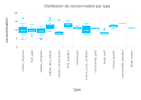

In [ ]:
# 2. Box plots par catégorie
p1 = plot(train, x=:type, y=:consommation, Geom.boxplot,
    Guide.title("Distribution de consommation par type"),
    Theme(background_color="white"))

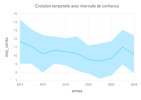

In [ ]:

# 3. Analyse temporelle avancée
# Calculer moyenne et écart-type par année
yearly_stats = combine(groupby(train, :annee),
    :consommation => mean => :moy_conso,
    :consommation => std => :std_conso)

p2 = plot(yearly_stats,
    x=:annee,
    y=:moy_conso,
    ymin=yearly_stats.moy_conso .- yearly_stats.std_conso,
    ymax=yearly_stats.moy_conso .+ yearly_stats.std_conso,
    Geom.line,
    Geom.ribbon,
    Guide.title("Évolution temporelle avec intervalle de confiance"),
    Theme(background_color="white"))

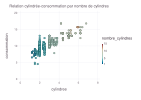

In [ ]:
# 4. Interaction cylindrée/nombre de cylindres
p3 = plot(train,
    x=:cylindree,
    y=:consommation,
    color=:nombre_cylindres,
    Geom.point,
    Guide.title("Relation cylindrée-consommation par nombre de cylindres"),
    Theme(background_color="white"))

In [15]:
# Statistiques descriptives par catégorie
cat_stats = combine(groupby(train, [:type, :transmission]),
    :consommation => mean => :conso_moyenne,
    :consommation => std => :conso_std,
    nrow => :count)

println("\nStatistiques par catégorie:")
display(cat_stats)


Statistiques par catégorie:


Row,type,transmission,conso_moyenne,conso_std,count
,String31,String15,Float64,Float64,Int64
1,voiture_moyenne,integrale,10.7516,1.8613,22
2,voiture_moyenne,propulsion,11.2341,3.34227,5
3,voiture_moyenne,traction,7.67265,1.39184,11
4,VUS_petit,integrale,10.1752,1.31886,50
5,VUS_petit,traction,9.45358,1.21144,49
6,VUS_petit,4x4,9.93476,1.05475,11
7,voiture_compacte,integrale,10.3699,1.24082,23
8,voiture_compacte,propulsion,10.2797,1.29771,17
9,voiture_compacte,traction,7.61577,1.28574,20


In [2]:
train = CSV.read("train.csv", DataFrame, decimal=',')
test = CSV.read("test.csv", DataFrame, decimal=',');

# Régression linéaire avec une seule variable explicative : nombre de cylindres

In [3]:
x = train.nombre_cylindres
y = train.consommation

n = length(y)

396

## Ajustement sur l'ensemble d'entraînement

In [9]:
using Statistics

ȳ = mean(y)
X = hcat(ones(n), x)

β̂ = X\y;

## Prédiction sur l'ensemble de test

In [10]:
x = test.nombre_cylindres
n = length(x)

X = hcat(ones(n), x)
ŷ = X*β̂

150-element Vector{Float64}:
  9.019013779206425
  9.019013779206425
  9.019013779206425
  9.019013779206425
 13.18218628207222
 13.18218628207222
 13.18218628207222
  9.019013779206425
 11.100600030639322
 15.263772533505119
 15.263772533505119
 17.345358784938018
  9.019013779206425
  ⋮
  9.019013779206425
 11.100600030639322
 13.18218628207222
  9.019013779206425
  9.019013779206425
  9.019013779206425
  9.019013779206425
  9.019013779206425
 11.100600030639322
 11.100600030639322
  7.978220653489975
  9.019013779206425

# Création du fichier de prédictions

In [11]:
id = 1:n

df_pred = DataFrame(id=id, consommation=ŷ)

CSV.write("benchmark.csv", df_pred)

"benchmark.csv"